1. Model and data

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)
from sklearn.preprocessing import LabelEncoder


#dataset
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df = pd.read_csv(
    data_url,
    names=columns,
    skipinitialspace=True
)

df = df.replace("?", pd.NA).dropna()
encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = encoder.fit_transform(df[column])

#features
X = df.drop(columns=["income"])
y = df["income"]

feature_names = list(X.columns)

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
#RandomForest model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
# Evaluation
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC score: {auc:.4f}\n")
print(classification_report(y_test, y_pred))
#Small subset for explanation methods
X_exp = X_test.iloc[:300].reset_index(drop=True)
#Example row index
sample_idx = 0
# Standard deviation of features
feature_std = X_train.std().values

Accuracy: 0.8273
ROC-AUC Score: 0.9168

              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4503
           1       0.62      0.83      0.71      1530

    accuracy                           0.83      6033
   macro avg       0.78      0.83      0.79      6033
weighted avg       0.85      0.83      0.83      6033



2. SHAP

 99%|===================| 596/600 [01:06<00:00]       

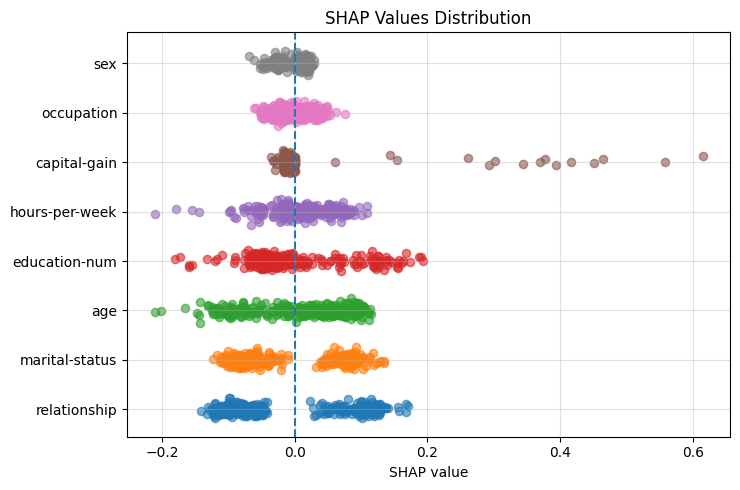

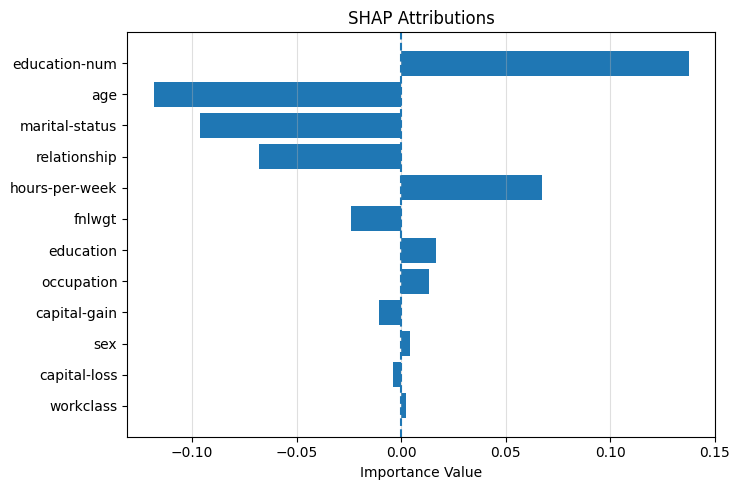

In [ ]:
import shap
background = shap.sample(X_train, 200, random_state=42)
explainer = shap.TreeExplainer(model, background)


def get_shap_values(explainer_obj, data):
    """
    Compatible with different SHAP versions.
    """

    values = explainer_obj.shap_values(data)

    if isinstance(values, list):
        return values[1]

    return values[:, :, 1]
sv = get_shap_values(explainer, X_exp)
importance = np.abs(sv).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)
#SHAP Global Features
top_features = importance_df.head(8)["feature"].tolist()
plt.figure(figsize=(7.5, 5))

for i, feature in enumerate(top_features):

    feature_idx = feature_names.index(feature)

    x_vals = sv[:, feature_idx]
    y_vals = np.random.normal(i, 0.08, size=len(x_vals))

    plt.scatter(
        x_vals,
        y_vals,
        alpha=0.6,
        s=35
    )

plt.axvline(0, linestyle="--")

plt.yticks(range(len(top_features)), top_features)
plt.xlabel("SHAP value")
plt.title("SHAP Values Distribution")

plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()
#SHAP Attribtuions
sample_values = sv[sample_idx]

local_df = pd.DataFrame({
    "feature": feature_names,
    "value": sample_values
})

local_df["abs_val"] = np.abs(local_df["value"])
local_df = local_df.sort_values("abs_val", ascending=False).head(12)

plt.figure(figsize=(7.5, 5))

plt.barh(
    local_df["feature"],
    local_df["value"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Importance Value")
plt.title("SHAP Attributions")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

3. LIME

In [ ]:
!pip install lime --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


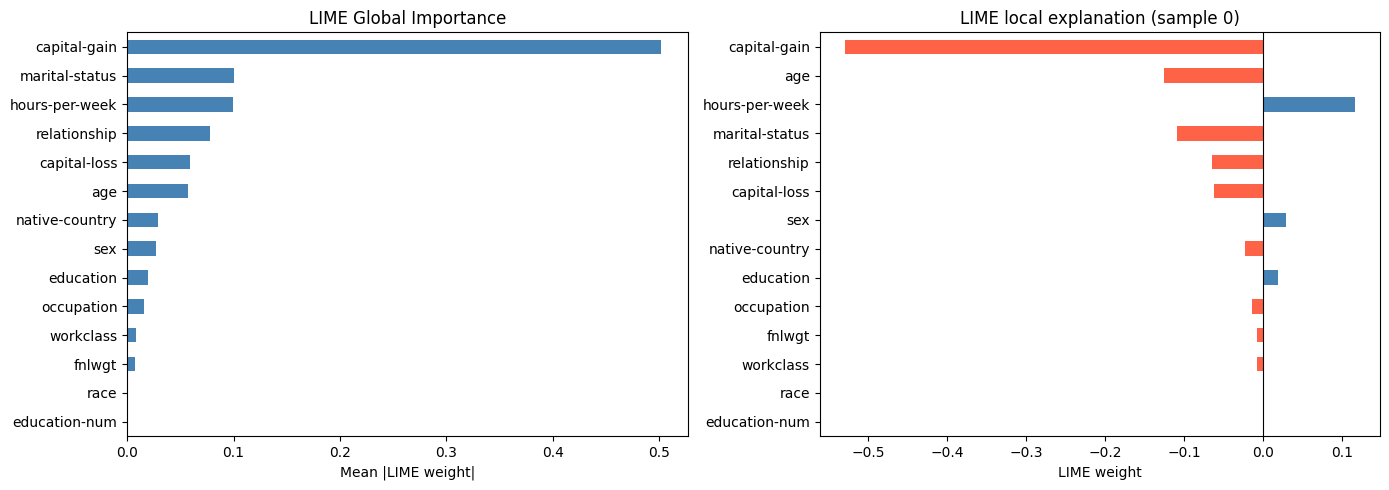

In [ ]:
import lime
import lime.lime_tabular
#LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    mode="classification",
    random_state=42
)


def get_lime_weights(sample):
    explanation = lime_explainer.explain_instance(
        sample,
        model.predict_proba,
        num_features=len(feature_names),
        num_samples=1000,
        labels=(1,)
    )

    weights_dict = {feature: 0.0 for feature in feature_names}

    for text, weight in explanation.as_list(label=1):

        for feature in feature_names:
            if feature in text:
                weights_dict[feature] = weight
                break

    return np.array([weights_dict[f] for f in feature_names])

lime_values = np.array([
    get_lime_weights(X_exp.iloc[i].values)
    for i in range(80)
])

#global importance
lime_global = pd.Series(
    np.abs(lime_values).mean(axis=0),
    index=feature_names
)

#local explanation for one instance
lime_local = get_lime_weights(X_exp.iloc[sample_idx].values)

#Global LIME
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lime_global.sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("LIME Global Importance")
axes[0].set_xlabel("Mean |LIME weight|")

#Local LIME
local_series = pd.Series(
    lime_local,
    index=feature_names
)

local_series = local_series.reindex(
    local_series.abs().sort_values().index
)

bar_colors = [
    "tomato" if value < 0 else "steelblue"
    for value in local_series
]

local_series.plot(
    kind="barh",
    ax=axes[1],
    color=bar_colors
)

axes[1].axvline(0, color="black", linewidth=0.8)

axes[1].set_title(f"LIME local explanation (sample {sample_idx})")
axes[1].set_xlabel("LIME weight")

plt.tight_layout()
plt.show()

4. SHAP vs LIME comparison

Spearman correlation SHAP vs LIME: -0.4246
P-value: 0.1302

Top 5 SHAP features:
{'marital-status', 'relationship', 'hours-per-week', 'education-num', 'age'}

Top 5 LIME features:
{'marital-status', 'relationship', 'hours-per-week', 'capital-gain', 'capital-loss'}

Shared features:
{'marital-status', 'relationship', 'hours-per-week'}


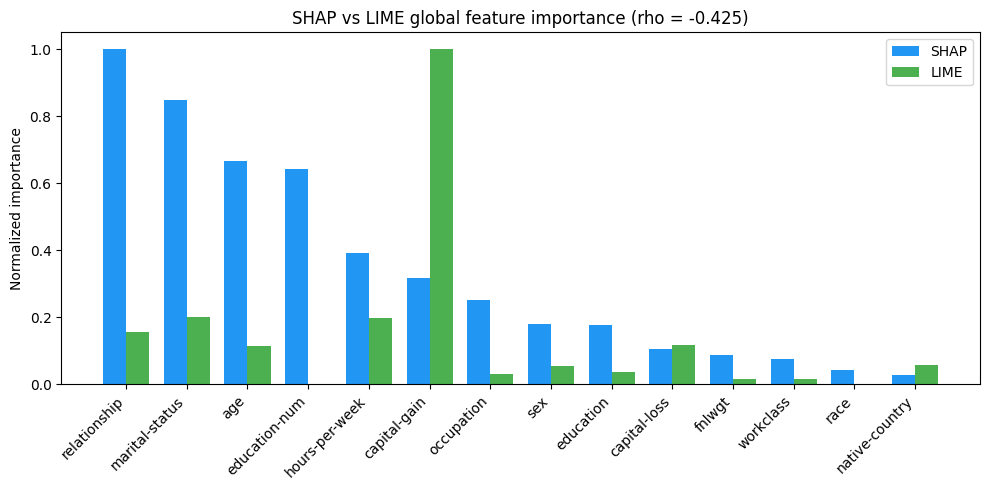

In [ ]:

#compare SHAP and LIME global importances
shap_global = global_importance
rho, p_value = spearmanr(shap_global, lime_global)

print(f"Spearman correlation SHAP vs LIME: {rho:.4f}")
print(f"P-value: {p_value:.4f}\n")
#top features from both methods
top_shap = set(shap_global.nlargest(5).index)
top_lime = set(lime_global.nlargest(5).index)

print("Top 5 SHAP features:")
print(top_shap)

print("\nTop 5 LIME features:")
print(top_lime)

print("\nShared features:")
print(top_shap & top_lime)

comparison_df = pd.DataFrame({
    "SHAP": shap_global / shap_global.max(),
    "LIME": lime_global / lime_global.max()
})

comparison_df = comparison_df.sort_values(
    by="SHAP",
    ascending=False
)
#plotting
positions = np.arange(len(comparison_df))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    positions - bar_width / 2,
    comparison_df["SHAP"],
    width=bar_width,
    label="SHAP",
    color="#2196F3"
)

ax.bar(
    positions + bar_width / 2,
    comparison_df["LIME"],
    width=bar_width,
    label="LIME",
    color="#4CAF50"
)

ax.set_xticks(positions)

ax.set_xticklabels(
    comparison_df.index,
    rotation=45,
    ha="right"
)

ax.set_ylabel("Normalized importance")

ax.set_title(
    f"SHAP vs LIME global feature importance (rho = {rho:.3f})"
)

ax.legend()

plt.tight_layout()
plt.show()

5. Stability under perbutations

In [ ]:

num_samples = 50
num_repeats = 10

noise_levels = [0.05, 0.10, 0.20]

X_stability = X_exp.iloc[:num_samples]

#Jaccard similarity
def top5_jaccard(values_a, values_b):
    top_a = set(np.argsort(np.abs(values_a))[-5:])
    top_b = set(np.argsort(np.abs(values_b))[-5:])

    return len(top_a & top_b) / len(top_a | top_b)


def compute_shap_values(data):

    values = explainer.shap_values(data)

    if isinstance(values, list):
        return values[1]

    return values[:, :, 1]

shap_original = compute_shap_values(X_stability)

lime_original = np.array([
    get_lime_weights(X_stability.iloc[i].values)
    for i in range(num_samples)
])


results = []

for sigma in noise_levels:

    shap_jaccard_scores = []
    shap_corr_scores = []

    lime_jaccard_scores = []
    lime_corr_scores = []

    for seed in range(num_repeats):

        rng = np.random.RandomState(seed)

        noise = rng.normal(
            loc=0,
            scale=sigma * feature_std,
            size=X_stability.shape
        )

        #Add perturbation
        perturbed = np.clip(
            X_stability.values + noise,
            X_train.min().values,
            X_train.max().values
        )

        X_perturbed = pd.DataFrame(
            perturbed,
            columns=feature_names
        )

        shap_perturbed = compute_shap_values(X_perturbed)

        lime_perturbed = np.array([
            get_lime_weights(X_perturbed.iloc[i].values)
            for i in range(num_samples)
        ])

        #compare explanations
        for idx in range(num_samples):

            shap_jaccard_scores.append(
                top5_jaccard(
                    shap_original[idx],
                    shap_perturbed[idx]
                )
            )

            shap_corr_scores.append(
                spearmanr(
                    shap_original[idx],
                    shap_perturbed[idx]
                )[0]
            )

            lime_jaccard_scores.append(
                top5_jaccard(
                    lime_original[idx],
                    lime_perturbed[idx]
                )
            )

            lime_corr_scores.append(
                spearmanr(
                    lime_original[idx],
                    lime_perturbed[idx]
                )[0]
            )

    results.append({
        "sigma": sigma,

        "SHAP J@5": np.mean(shap_jaccard_scores),
        "SHAP J@5 std": np.std(shap_jaccard_scores),

        "SHAP rho": np.mean(shap_corr_scores),
        "SHAP rho std": np.std(shap_corr_scores),

        "LIME J@5": np.mean(lime_jaccard_scores),
        "LIME J@5 std": np.std(lime_jaccard_scores),

        "LIME rho": np.mean(lime_corr_scores),
        "LIME rho std": np.std(lime_corr_scores)
    })

    print(
        f"Noise={sigma:.2f} | "
        f"SHAP J@5={np.mean(shap_jaccard_scores):.3f}, "
        f"SHAP rho={np.mean(shap_corr_scores):.3f} | "
        f"LIME J@5={np.mean(lime_jaccard_scores):.3f}, "
        f"LIME rho={np.mean(lime_corr_scores):.3f}"
    )


#Final results table
results_df = pd.DataFrame(results)



 99%|===================| 99/100 [00:13<00:00]       

Noise=0.05 | SHAP J@5=0.934, SHAP rho=0.982 | LIME J@5=0.749, LIME rho=0.358
Noise=0.10 | SHAP J@5=0.877, SHAP rho=0.956 | LIME J@5=0.755, LIME rho=0.363
Noise=0.20 | SHAP J@5=0.796, SHAP rho=0.875 | LIME J@5=0.739, LIME rho=0.346


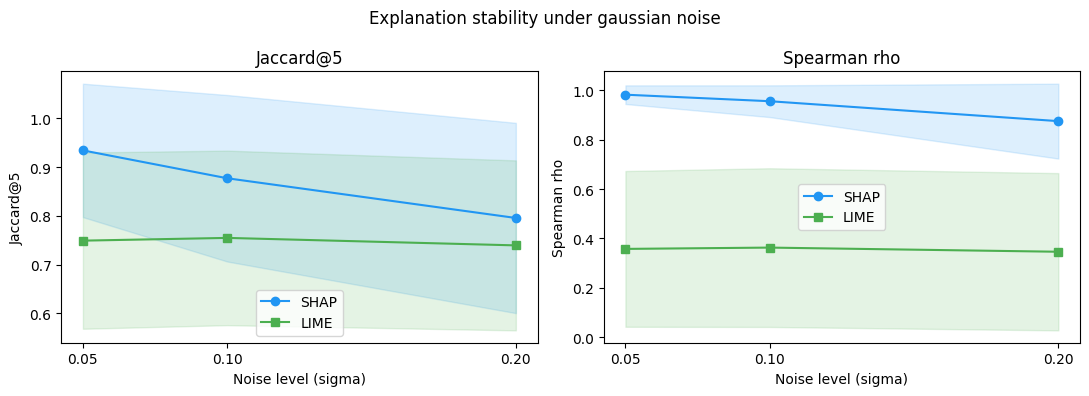

 sigma  SHAP J@5  SHAP rho  LIME J@5  LIME rho
  0.05  0.934095  0.981978  0.749048  0.357718
  0.10  0.876952  0.955552  0.754690  0.363005
  0.20  0.795524  0.874919  0.739333  0.346168


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_settings = [
    (
        "SHAP J@5",
        "LIME J@5",
        "SHAP J@5 std",
        "LIME J@5 std",
        "Jaccard@5"
    ),
    (
        "SHAP rho",
        "LIME rho",
        "SHAP rho std",
        "LIME rho std",
        "Spearman rho"
    )
]


for ax, settings in zip(axes, plot_settings):
    shap_mean, lime_mean, shap_std, lime_std, ylabel = settings
    ax.plot(
        results_df["sigma"],
        results_df[shap_mean],
        "o-",
        label="SHAP",
        color="#2196F3"
    )

    ax.fill_between(
        results_df["sigma"],
        results_df[shap_mean] - results_df[shap_std],
        results_df[shap_mean] + results_df[shap_std],
        alpha=0.15,
        color="#2196F3"
    )

    ax.plot(
        results_df["sigma"],
        results_df[lime_mean],
        "s-",
        label="LIME",
        color="#4CAF50"
    )

    ax.fill_between(
        results_df["sigma"],
        results_df[lime_mean] - results_df[lime_std],
        results_df[lime_mean] + results_df[lime_std],
        alpha=0.15,
        color="#4CAF50"
    )

    ax.set_xlabel("Noise level (sigma)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xticks(noise_levels)
    ax.legend()
fig.suptitle(
    "Explanation stability under gaussian noise",
    fontsize=12
)

plt.tight_layout()
plt.show()
summary_cols = [
    "sigma",
    "SHAP J@5",
    "SHAP rho",
    "LIME J@5",
    "LIME rho"
]

print(
    results_df[summary_cols].to_string(index=False)
)
